# LA AURORA

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Tensorflow
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import MeanSquaredError, RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error


#Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

/Users/marinesgarcia/Documents/UVG/DS/Lab1DS/lab1ds/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Carga de archivos

In [2]:
train = pd.read_csv("../Datos/train.csv")
test = pd.read_csv("../Datos/test.csv")

In [3]:
#filtrar turistas y excursionistas
train = train[
    train["Tipo de Viajero"].isin(
        ["Turista","Excursionista"]
    )
]

test = test[
    test["Tipo de Viajero"].isin(
        ["Turista","Excursionista"]
    )
]

In [4]:
tf.random.set_seed(123)

train["Fecha"] = pd.to_datetime(train["Fecha"])

print("\nParsed Data:")
print(train.head())


Parsed Data:
    Año  Mes cod  Mes    Vía      Frontera            País  \
0  2009        1  Ene  Aérea  01 La Aurora         Albania   
1  2009        1  Ene  Aérea  01 La Aurora        Alemania   
2  2009        1  Ene  Aérea  01 La Aurora          Angola   
3  2009        1  Ene  Aérea  01 La Aurora  Arabia Saudita   
4  2009        1  Ene  Aérea  01 La Aurora         Argelia   

                   Región              Región dos       Regiones OMT  \
0          OTROS EUROPEOS                  Europa  EUROPA MERIDIONAL   
1                  EUROPA                  Europa  EUROPA OCCIDENTAL   
2  OTROS PAISES DEL MUNDO  Otros Paises Del Mundo     ÁFRICA CENTRAL   
3     OTROS ORIENTE MEDIO           Oriente Medio      ORIENTE MEDIO   
4  OTROS PAISES DEL MUNDO  Otros Paises Del Mundo   ÁFRICA DEL NORTE   

        MCEO Agrupación Residencia Tipo de Viajero  Viajero      Fecha  
0   08 OTROS                Europa         Turista      1.0 2009-01-01  
1  04 EUROPA                Europa

In [5]:
test["Fecha"] = pd.to_datetime(test["Fecha"])

print("\nParsed Data:")
print(test.head())


Parsed Data:
    Año  Mes cod  Mes    Vía      Frontera       País           Región  \
1  2021        4  Abr  Aérea  01 La Aurora   Alemania           EUROPA   
2  2021        4  Abr  Aérea  01 La Aurora  Argentina  AMÉRICA DEL SUR   
4  2021        4  Abr  Aérea  01 La Aurora    Austria           EUROPA   
5  2021        4  Abr  Aérea  01 La Aurora    Bahamas  OTROS CARIBEÑOS   
6  2021        4  Abr  Aérea  01 La Aurora   Barbados  OTROS CARIBEÑOS   

                    Región dos       Regiones OMT           MCEO  \
1                       Europa  EUROPA OCCIDENTAL      04 EUROPA   
2  América Del Sur y el Caribe    AMÉRICA DEL SUR  03 SUDAMÉRICA   
4                       Europa  EUROPA OCCIDENTAL       08 OTROS   
5  América Del Sur y el Caribe          EL CARIBE       08 OTROS   
6  América Del Sur y el Caribe          EL CARIBE       08 OTROS   

  Agrupación Residencia Tipo de Viajero     Viajero      Fecha  
1                Europa         Turista  229.534884 2021-04-01  
2 

## Serie

In [6]:
train_serie = (
    train[
        train["Frontera"]=="01 La Aurora"
    ]
    .groupby("Fecha")["Viajero"]
    .sum()
    .asfreq("MS")
)

test_serie = (
    test[
        test["Frontera"]=="01 La Aurora"
    ]
    .groupby("Fecha")["Viajero"]
    .sum()
    .asfreq("MS")
)

In [7]:
print(type(train_serie))
print(train_serie.head())
print(train_serie.index)

<class 'pandas.core.series.Series'>
Fecha
2009-01-01    81271.0
2009-02-01    69663.0
2009-03-01    84051.0
2009-04-01    80247.0
2009-05-01    64456.0
Freq: MS, Name: Viajero, dtype: float64
DatetimeIndex(['2009-01-01', '2009-02-01', '2009-03-01', '2009-04-01',
               '2009-05-01', '2009-06-01', '2009-07-01', '2009-08-01',
               '2009-09-01', '2009-10-01',
               ...
               '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01',
               '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01',
               '2021-02-01', '2021-03-01'],
              dtype='datetime64[ns]', name='Fecha', length=147, freq='MS')


## Info de la serie

In [8]:
print("Inicio:", train_serie.index.min())

print("Fin:", train_serie.index.max())

print("Frecuencia:", train_serie.index.freq)

Inicio: 2009-01-01 00:00:00
Fin: 2021-03-01 00:00:00
Frecuencia: <MonthBegin>


## Gráfica de la serie

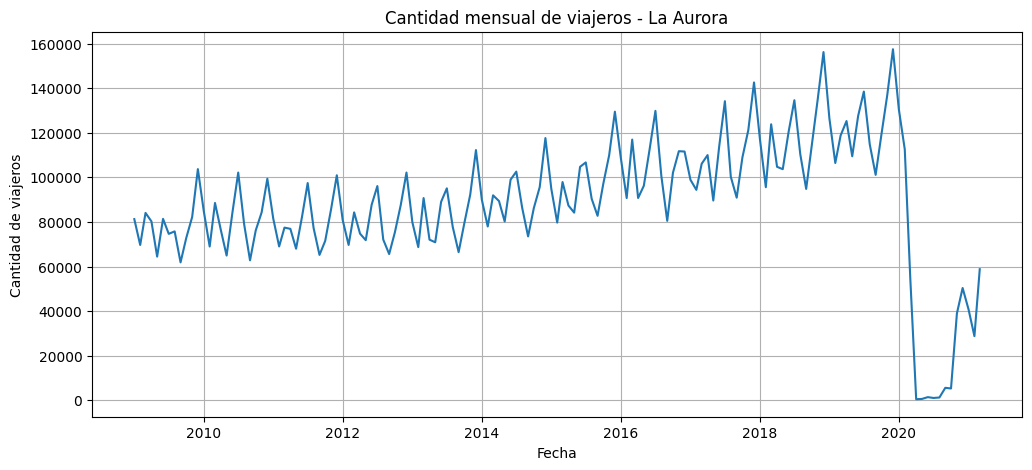

In [9]:
plt.figure(figsize=(12,5))

plt.plot(train_serie.index, train_serie.values)

plt.title("Cantidad mensual de viajeros - La Aurora")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.grid(True)

plt.show()

In [10]:
mediaMovil = train_serie.rolling(window=12).mean()
deMovil = train_serie.rolling(window=12).std()

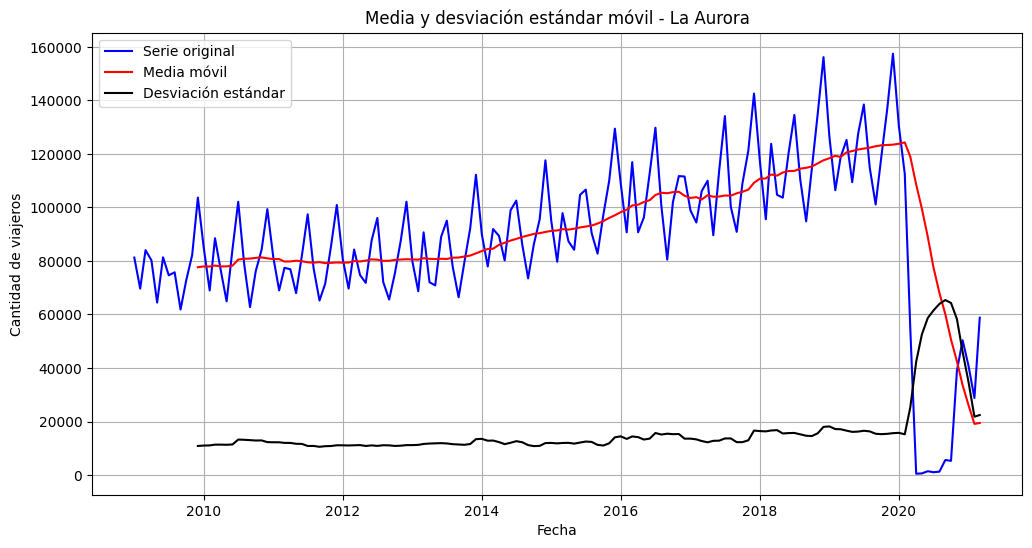

In [11]:
plt.figure(figsize=(12,6))

plt.plot(train_serie.index, train_serie.values,
         label="Serie original", color="blue")

plt.plot(mediaMovil.index, mediaMovil,
         label="Media móvil", color="red")

plt.plot(deMovil.index, deMovil,
         label="Desviación estándar", color="black")

plt.title("Media y desviación estándar móvil - La Aurora")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.legend()

plt.grid(True)

plt.show()

## Descomposición de la serie

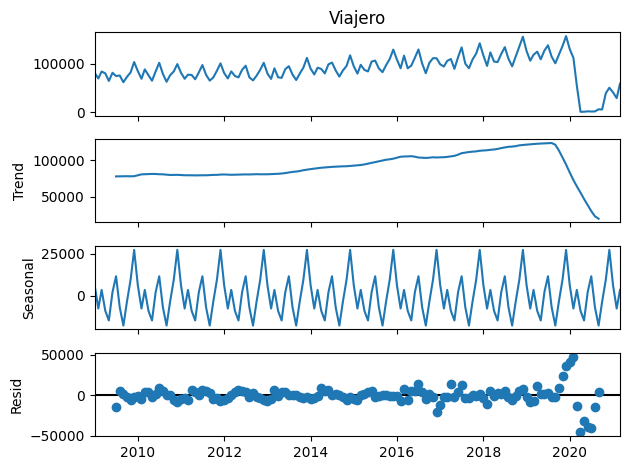

In [12]:
descomposicion = seasonal_decompose(train_serie)
descomposicion.plot();

## Transformación de la serie

In [13]:
print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(train_serie, autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba         -2.369729
p-value                        0.150463
# de retardos usados          14.000000
# de observaciones usadas    132.000000
Critical Value (1%)           -3.480888
Critical Value (5%)           -2.883697
Critical Value (10%)          -2.578586
dtype: float64


In [14]:
print('Resultados del Test de Dickey Fuller para una diferenciación de la serie')
train_serie_diff = train_serie.diff()
train_serie_diff.fillna(0,inplace=True)
dfTest = adfuller(train_serie_diff)
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller para una diferenciación de la serie
Estadístico de prueba         -4.119860
p-value                        0.000898
# de retardos usados          14.000000
# de observaciones usadas    132.000000
Critical Value (1%)           -3.480888
Critical Value (5%)           -2.883697
Critical Value (10%)          -2.578586
dtype: float64


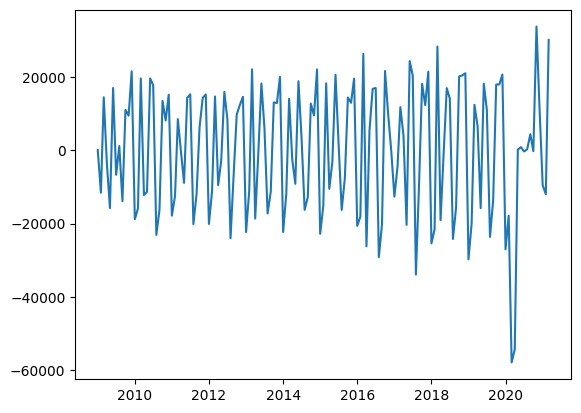

In [15]:
plt.plot(train_serie_diff)

## Es estacionaria

<Figure size 1000x500 with 0 Axes>

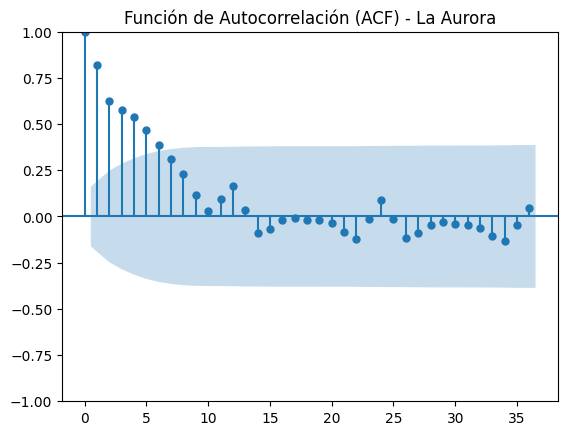

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(train_serie, lags=36)

plt.title("Función de Autocorrelación (ACF) - La Aurora")

plt.show()

<Figure size 1000x500 with 0 Axes>

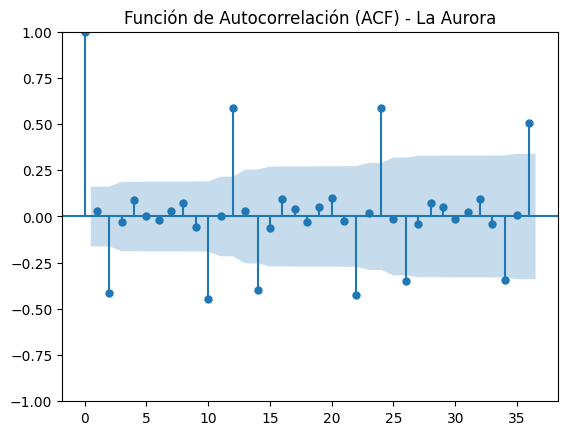

In [17]:
plt.figure(figsize=(10,5))

plot_acf(train_serie_diff, lags=36)

plt.title("Función de Autocorrelación (ACF) - La Aurora")

plt.show()

## Selección de parámetros

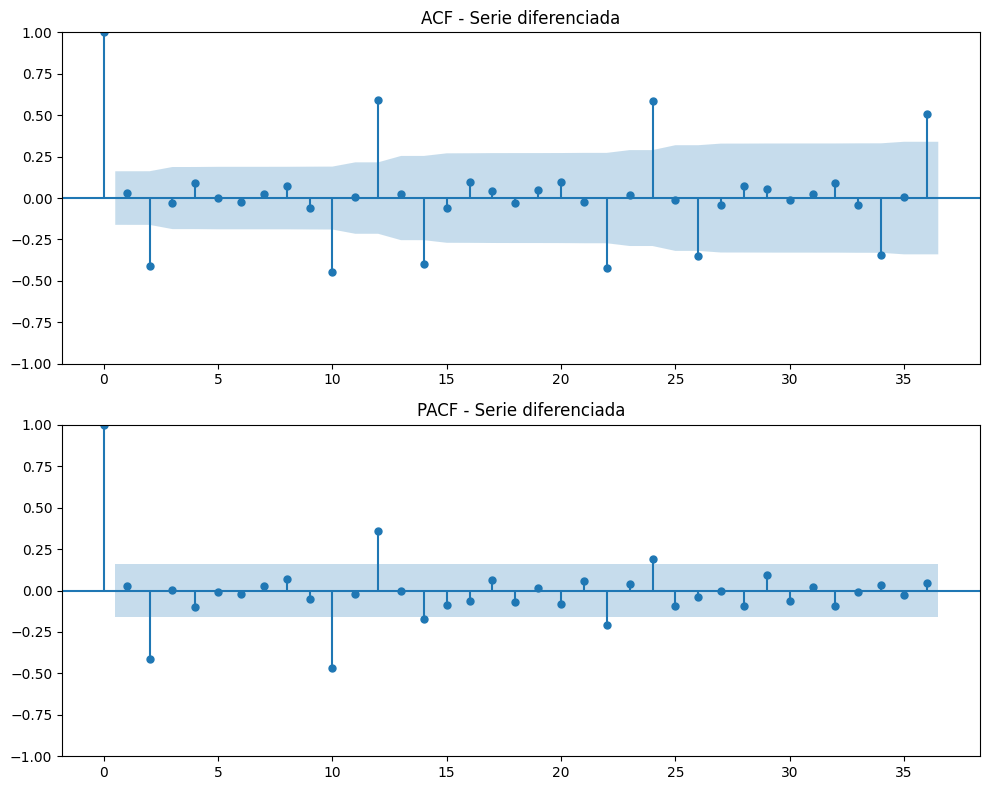

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(10,8))

plot_acf(train_serie_diff, lags=36, ax=ax[0])
ax[0].set_title("ACF - Serie diferenciada")

plot_pacf(train_serie_diff, lags=36, ax=ax[1])
ax[1].set_title("PACF - Serie diferenciada")

plt.tight_layout()
plt.show()

## Creación de modelos

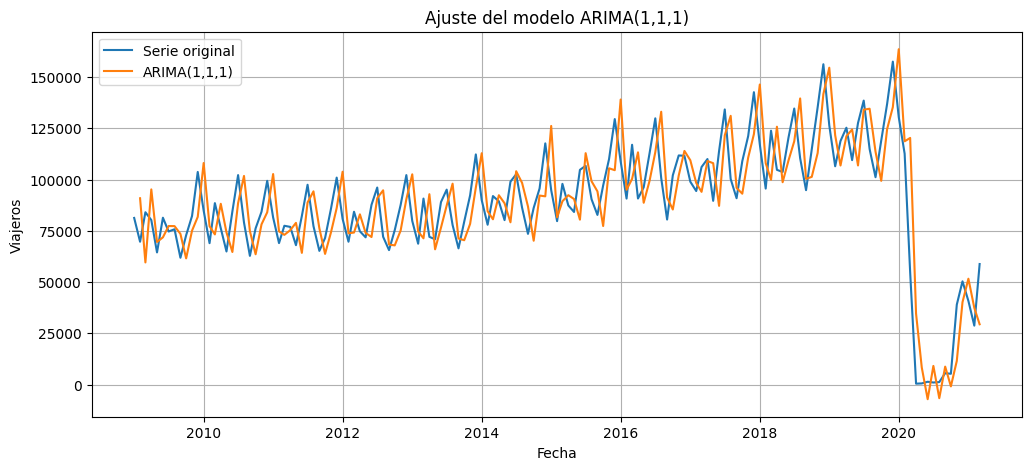

In [19]:
from statsmodels.tsa.arima.model import ARIMA

modelo_111 = ARIMA(train_serie, order=(1,1,1)).fit()

ajuste = modelo_111.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(1,1,1)")

plt.title("Ajuste del modelo ARIMA(1,1,1)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

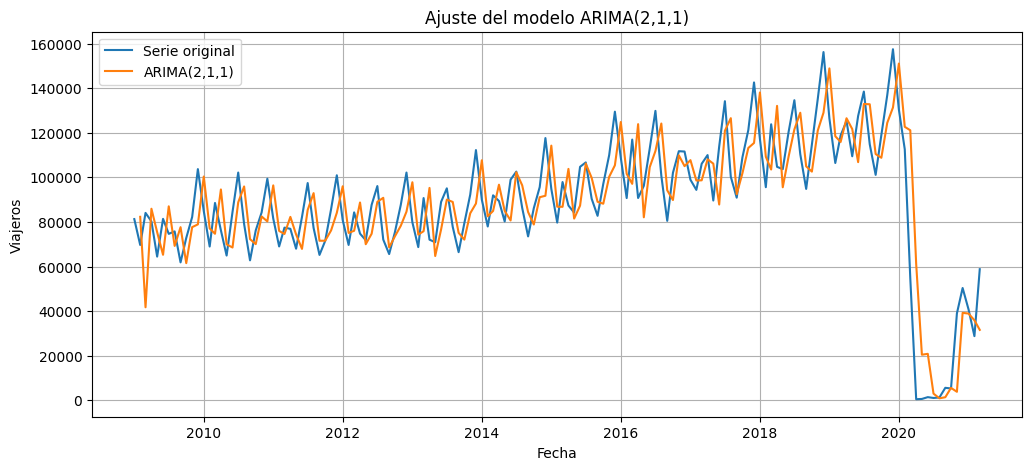

In [20]:
modelo_211 = ARIMA(train_serie, order=(2,1,1)).fit()

ajuste = modelo_211.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(2,1,1)")

plt.title("Ajuste del modelo ARIMA(2,1,1)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

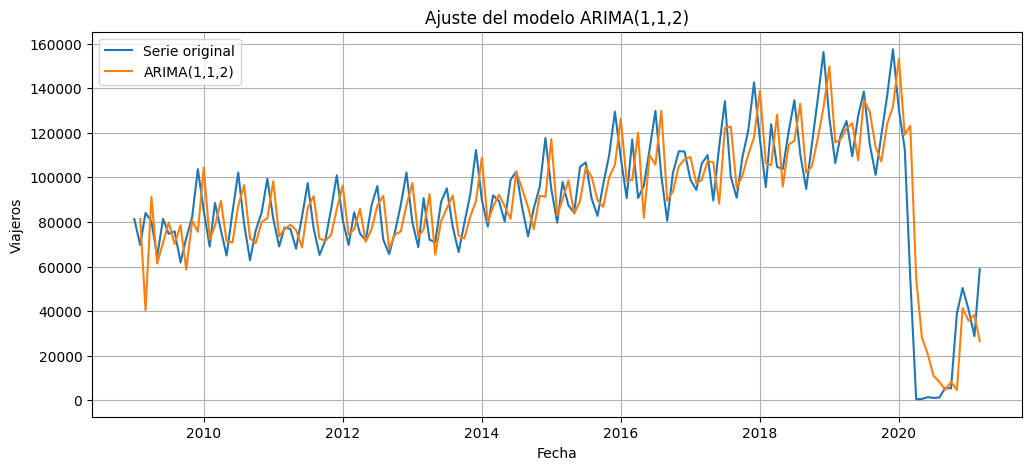

In [21]:
modelo_112 = ARIMA(train_serie, order=(1,1,2)).fit()

ajuste = modelo_112.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(1,1,2)")

plt.title("Ajuste del modelo ARIMA(1,1,2)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

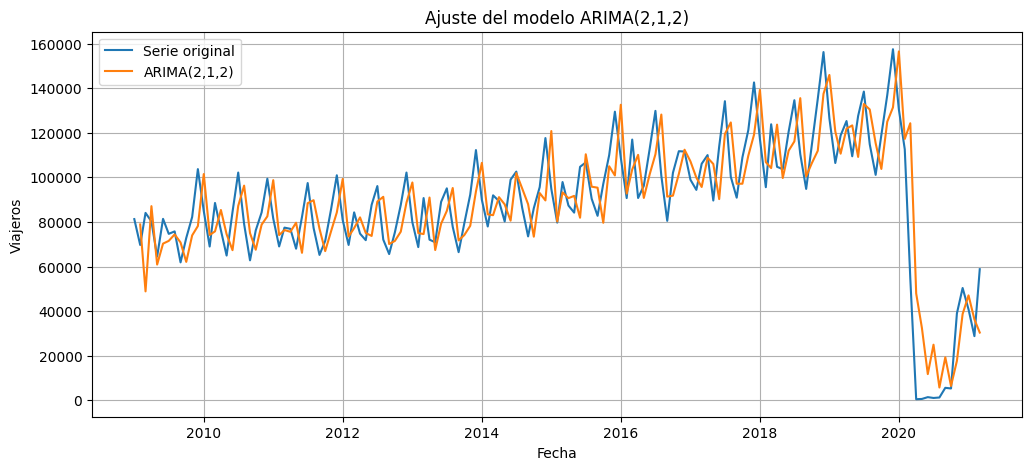

In [22]:
modelo_212 = ARIMA(train_serie, order=(2,1,2)).fit()

ajuste = modelo_212.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(2,1,2)")

plt.title("Ajuste del modelo ARIMA(2,1,2)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

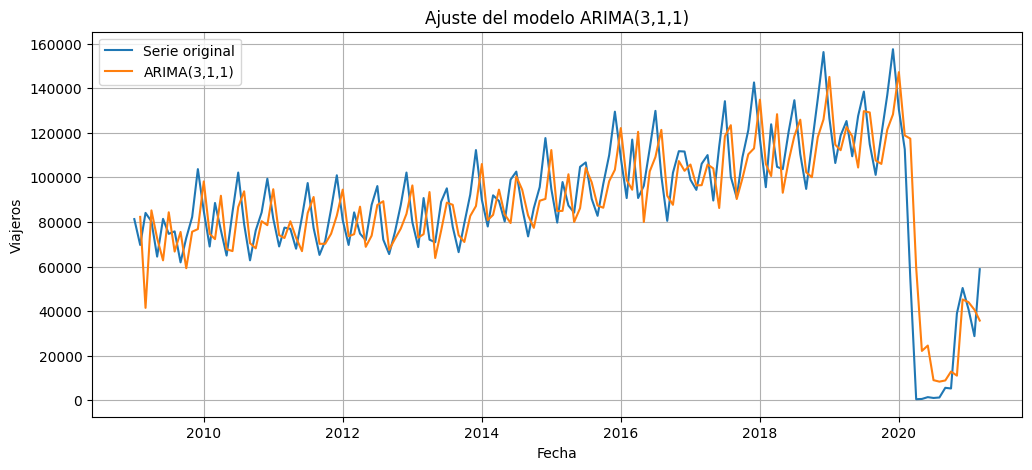

In [23]:
modelo_311 = ARIMA(train_serie, order=(3,1,1)).fit()

ajuste = modelo_311.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(3,1,1)")

plt.title("Ajuste del modelo ARIMA(3,1,1)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()


Modelo ARIMA(1, 1, 1)


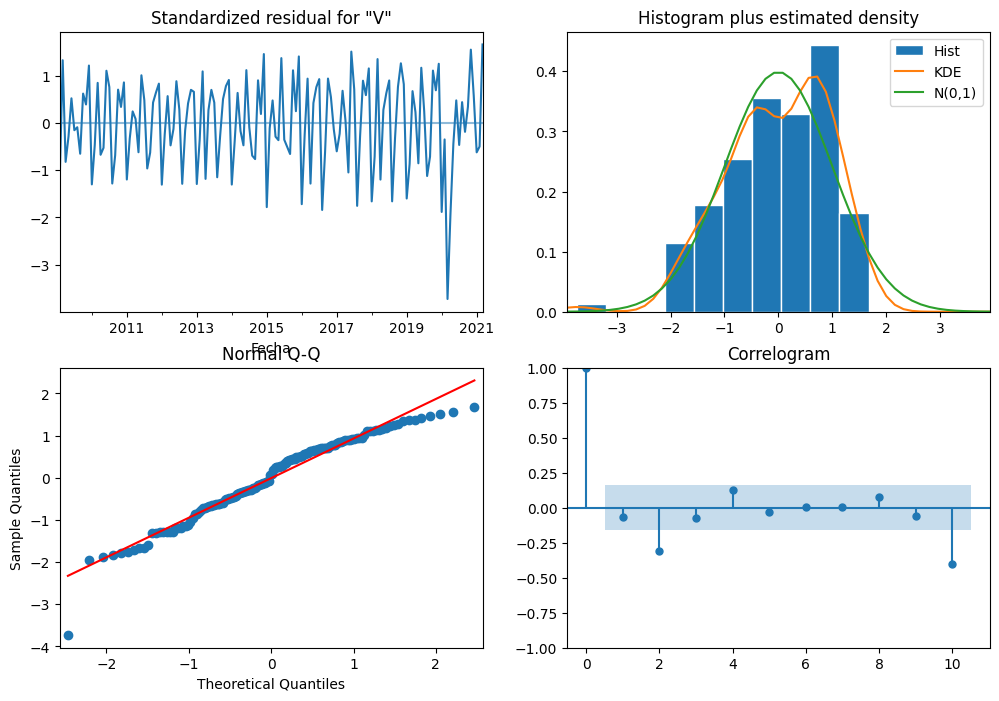


Modelo ARIMA(2, 1, 1)


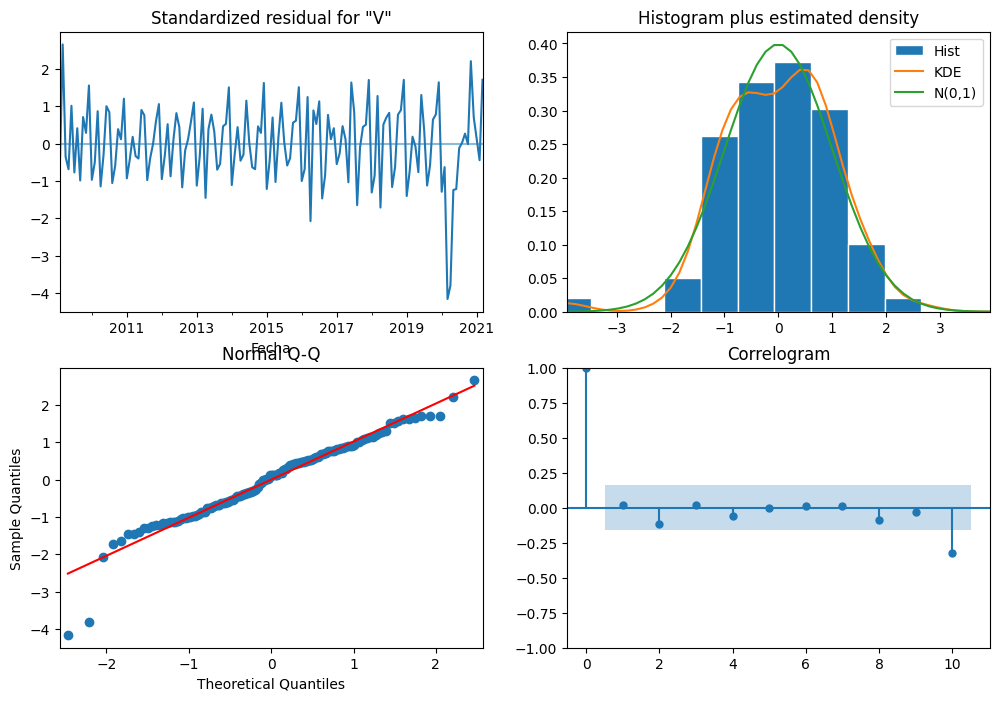


Modelo ARIMA(1, 1, 2)


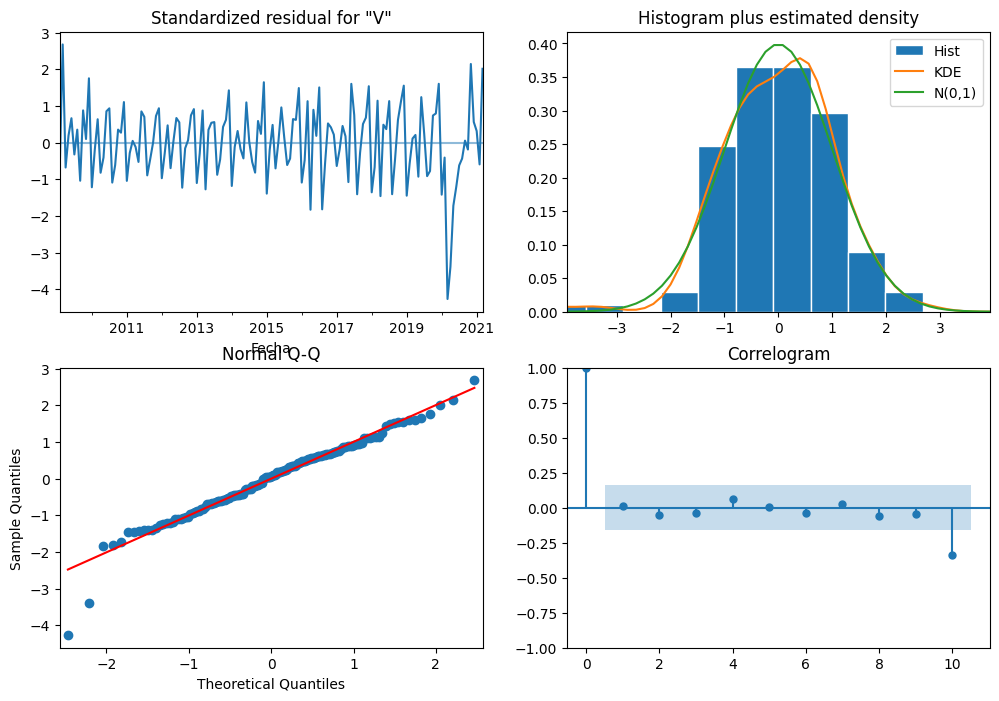


Modelo ARIMA(2, 1, 2)


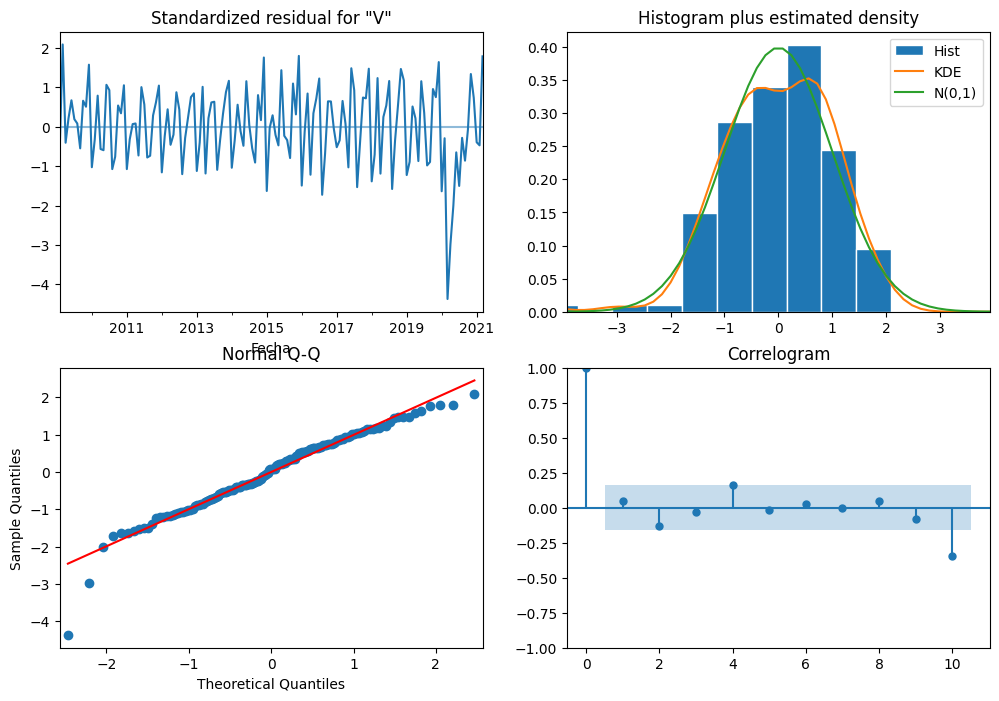


Modelo ARIMA(3, 1, 1)


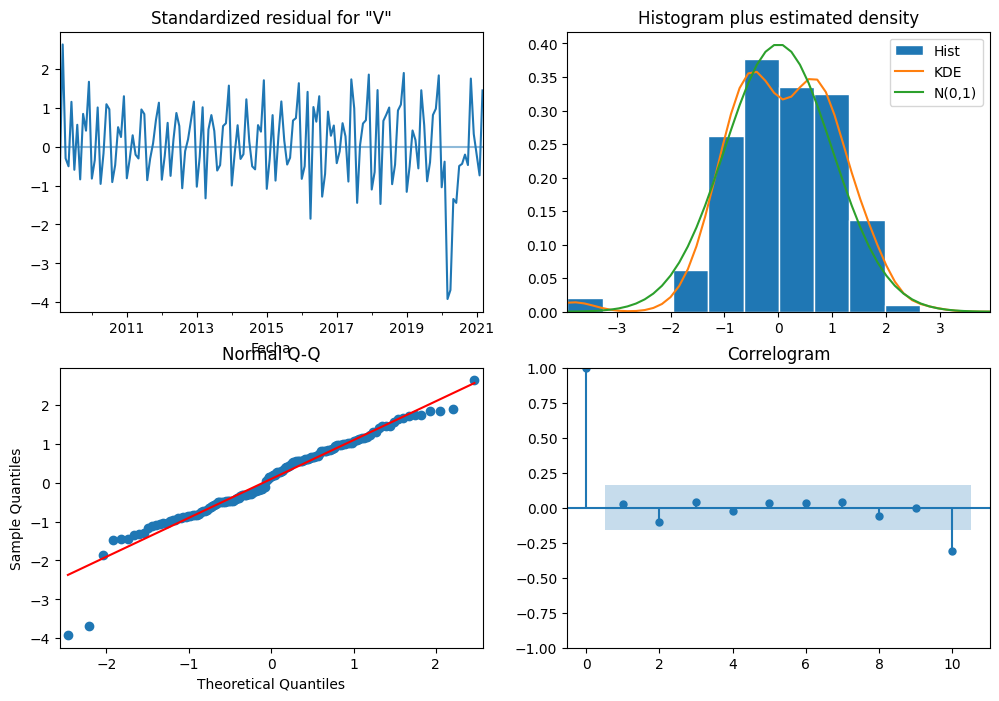

In [24]:
modelos = [
    (1,1,1),
    (2,1,1),
    (1,1,2),
    (2,1,2),
    (3,1,1)
]

for orden in modelos:

    modelo = ARIMA(train_serie, order=orden).fit()

    print(f"\nModelo ARIMA{orden}")

    modelo.plot_diagnostics(figsize=(12,8))

    plt.show()

In [25]:
from statsmodels.tsa.arima.model import ARIMA

resultados = []

for orden in modelos:

    modelo = ARIMA(train_serie, order=orden)
    modelo_fit = modelo.fit()

    resultados.append({
        "Modelo": f"ARIMA{orden}",
        "AIC": modelo_fit.aic,
        "BIC": modelo_fit.bic
    })

resultados = pd.DataFrame(resultados)

resultados.sort_values("AIC")

,Modelo,AIC,BIC
3,"ARIMA(2, 1, 2)",3249.256197,3264.174230
2,"ARIMA(1, 1, 2)",3250.869625,3262.804052
4,"ARIMA(3, 1, 1)",3252.748159,3267.666193
1,"ARIMA(2, 1, 1)",3253.782658,3265.717084
0,"ARIMA(1, 1, 1)",3258.362775,3267.313595


In [26]:
mejor_arima = ARIMA(train_serie, order=(2,1,2)).fit()

pred_arima = mejor_arima.forecast(steps=len(test_serie))

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test_serie, pred_arima)

rmse_arima = np.sqrt(
    mean_squared_error(test_serie, pred_arima)
)

print("ARIMA (2,1,2)")
print(f"MAE : {mae_arima:.2f}")
print(f"RMSE: {rmse_arima:.2f}")

ARIMA (2,1,2)
MAE : 47832.98
RMSE: 52589.03


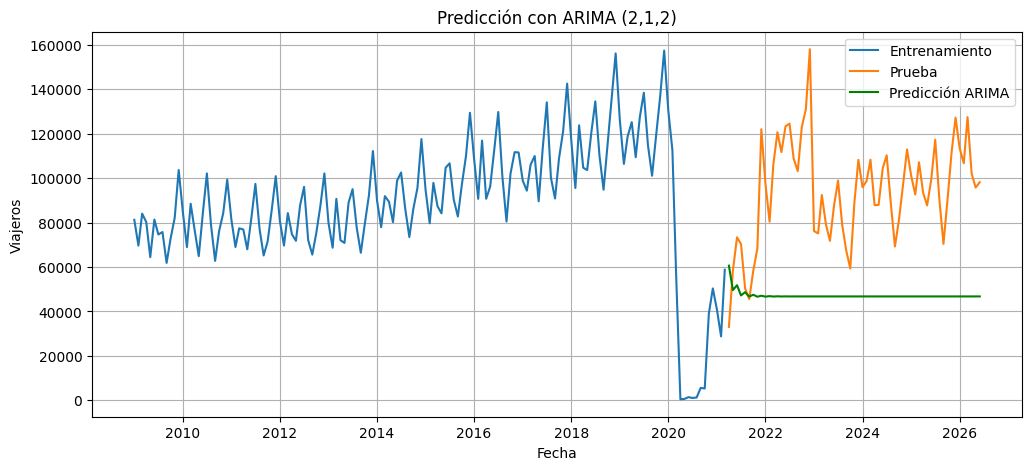

In [28]:
plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Entrenamiento")
plt.plot(test_serie, label="Prueba")
plt.plot(test_serie.index,
         pred_arima,
         label="Predicción ARIMA",
         color="green")

plt.title("Predicción con ARIMA (2,1,2)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

## Modelos alternativos

### Holt-Winters

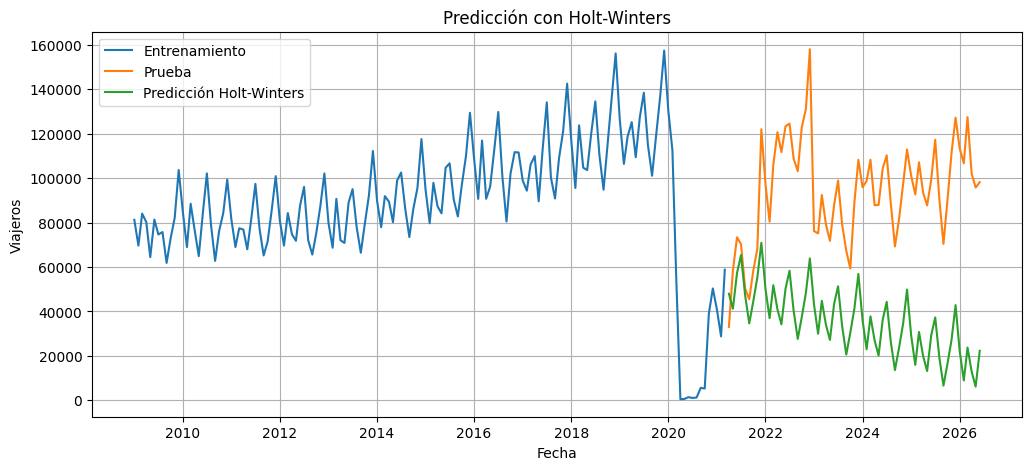

Holt-Winters
MAE : 59367.58036280113
RMSE: 64047.06504491762


In [29]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelo_hw = ExponentialSmoothing(
    train_serie,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

pred_hw = modelo_hw.forecast(len(test_serie))

mae_hw = mean_absolute_error(test_serie, pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test_serie, pred_hw))

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Entrenamiento")
plt.plot(test_serie, label="Prueba")
plt.plot(test_serie.index, pred_hw, label="Predicción Holt-Winters")

plt.title("Predicción con Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

print("Holt-Winters")
print("MAE :", mae_hw)
print("RMSE:", rmse_hw)

### Prophet

Importing plotly failed. Interactive plots will not work.
10:41:13 - cmdstanpy - INFO - Chain [1] start processing
10:41:13 - cmdstanpy - INFO - Chain [1] done processing


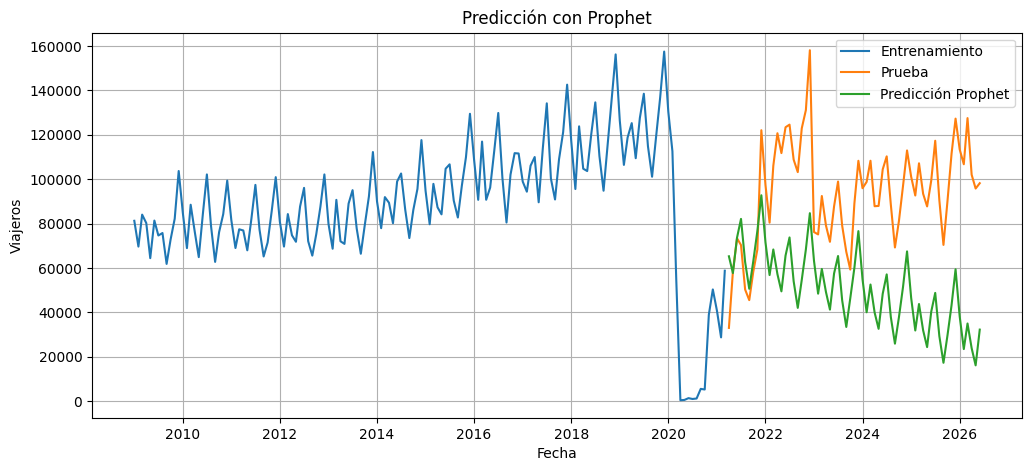

Prophet
MAE : 45971.28430031279
RMSE: 50960.96931600338


In [30]:
from prophet import Prophet

prophet_train = train_serie.reset_index()
prophet_train.columns = ["ds", "y"]

modelo_prophet = Prophet()

modelo_prophet.fit(prophet_train)

future = modelo_prophet.make_future_dataframe(
    periods=len(test_serie),
    freq="MS"
)

forecast = modelo_prophet.predict(future)

pred_prophet = forecast.tail(len(test_serie))["yhat"].values

mae_prophet = mean_absolute_error(test_serie, pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(test_serie, pred_prophet))

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Entrenamiento")
plt.plot(test_serie, label="Prueba")
plt.plot(test_serie.index, pred_prophet, label="Predicción Prophet")

plt.title("Predicción con Prophet")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

print("Prophet")
print("MAE :", mae_prophet)
print("RMSE:", rmse_prophet)

### Seasonal Naive

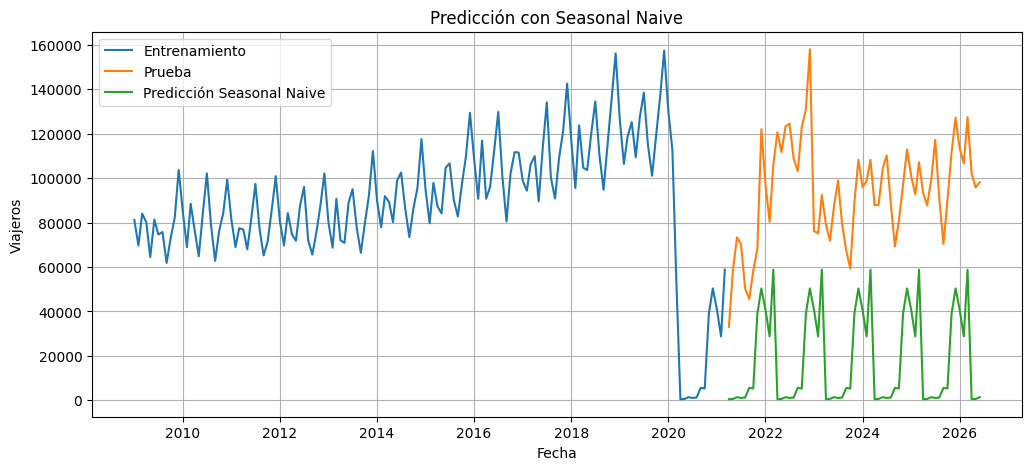

Seasonal Naive
MAE : 75518.44036960739
RMSE: 79320.75972667034


In [31]:
pred_naive = np.tile(
    train_serie.iloc[-12:].values,
    int(np.ceil(len(test_serie)/12))
)

pred_naive = pred_naive[:len(test_serie)]

pred_naive = pd.Series(
    pred_naive,
    index=test_serie.index
)

mae_naive = mean_absolute_error(test_serie, pred_naive)
rmse_naive = np.sqrt(mean_squared_error(test_serie, pred_naive))

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Entrenamiento")
plt.plot(test_serie, label="Prueba")
plt.plot(test_serie.index, pred_naive, label="Predicción Seasonal Naive")

plt.title("Predicción con Seasonal Naive")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

print("Seasonal Naive")
print("MAE :", mae_naive)
print("RMSE:", rmse_naive)

In [32]:
comparacion = pd.DataFrame({
    "Modelo": [
        "ARIMA (2,1,2)",
        "Holt-Winters",
        "Prophet",
        "Seasonal Naive"
    ],
    "MAE": [
        mae_arima,
        mae_hw,
        mae_prophet,
        mae_naive
    ],
    "RMSE": [
        rmse_arima,
        rmse_hw,
        rmse_prophet,
        rmse_naive
    ]
})

comparacion = comparacion.sort_values("RMSE")

print(comparacion)

           Modelo           MAE          RMSE
2         Prophet  45971.284300  50960.969316
0   ARIMA (2,1,2)  47832.984779  52589.030465
1    Holt-Winters  59367.580363  64047.065045
3  Seasonal Naive  75518.440370  79320.759727


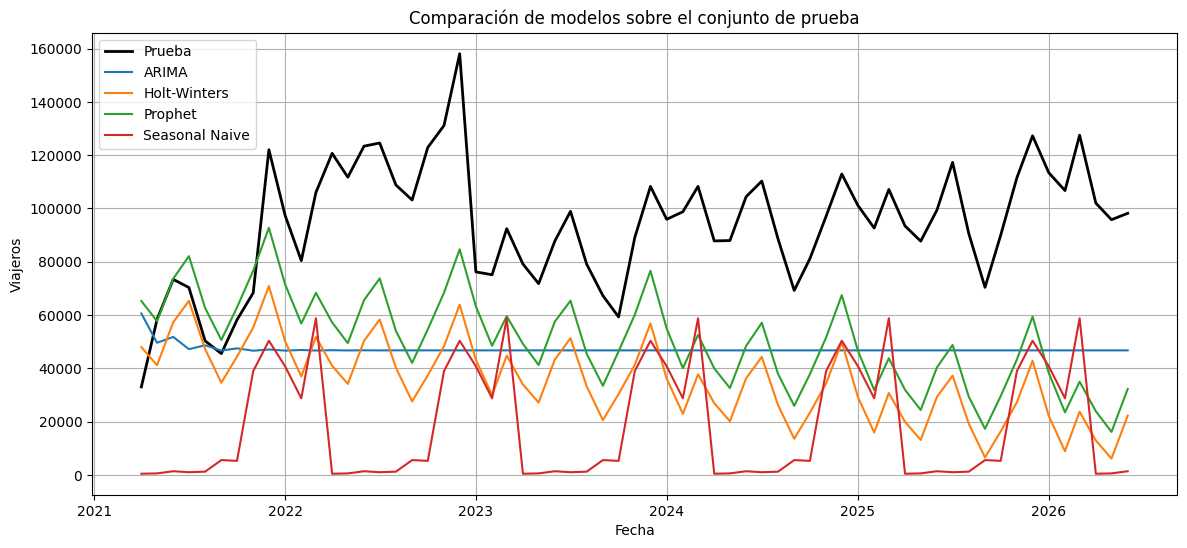

In [33]:
plt.figure(figsize=(14,6))

plt.plot(test_serie, label="Prueba", color="black", linewidth=2)

plt.plot(test_serie.index, pred_arima, label="ARIMA")
plt.plot(test_serie.index, pred_hw, label="Holt-Winters")
plt.plot(test_serie.index, pred_prophet, label="Prophet")
plt.plot(test_serie.index, pred_naive, label="Seasonal Naive")

plt.title("Comparación de modelos sobre el conjunto de prueba")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

## Predicción

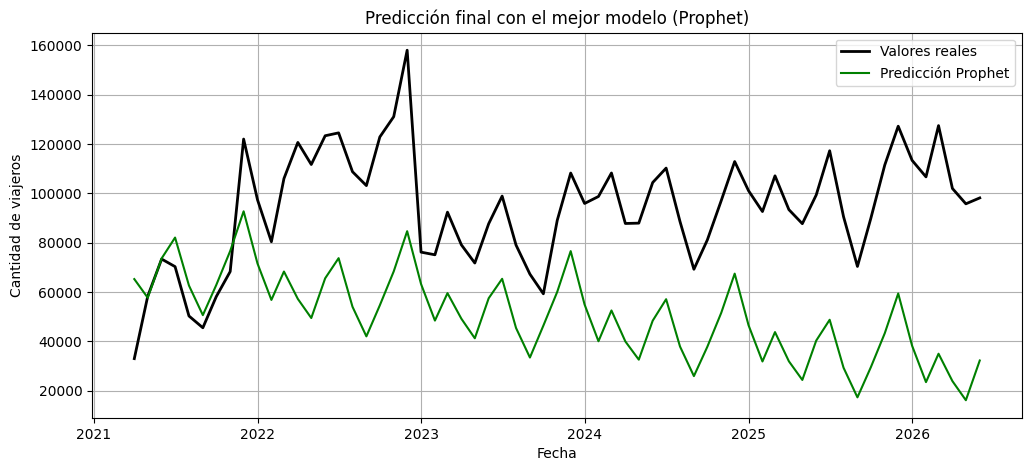

In [34]:
plt.figure(figsize=(12,5))

plt.plot(test_serie.index, test_serie,
         label="Valores reales",
         color="black",
         linewidth=2)

plt.plot(test_serie.index, pred_prophet,
         label="Predicción Prophet",
         color="green")

plt.title("Predicción final con el mejor modelo (Prophet)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.legend()
plt.grid(True)

plt.show()

In [35]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.random.set_seed(123)
np.random.seed(123)

def crear_secuencias(datos_escalados, ventana):
    X, y = [], []
    for i in range(len(datos_escalados) - ventana):
        X.append(datos_escalados[i:i+ventana, 0])
        y.append(datos_escalados[i+ventana, 0])
    return np.array(X), np.array(y)

def construir_modelo(ventana, capas_unidades, dropout, lr):
    modelo = Sequential()
    modelo.add(Input(shape=(ventana, 1)))
    for idx, unidades in enumerate(capas_unidades):
        return_seq = idx < len(capas_unidades) - 1
        modelo.add(LSTM(unidades, return_sequences=return_seq))
        modelo.add(Dropout(dropout))
    modelo.add(Dense(1))
    modelo.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return modelo

def evaluar_config(train_serie, ventana, capas_unidades, dropout, lr, batch_size, epochs=100):
    """Entrena con un split interno 80/20 (cronológico) y devuelve RMSE/MAE de validación."""
    valores = train_serie.values.reshape(-1, 1).astype(float)

    corte = int(len(valores) * 0.8)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(valores[:corte])  # ajustar SOLO con la parte de entrenamiento real
    valores_esc = scaler.transform(valores)

    X, y = crear_secuencias(valores_esc, ventana)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    corte_secuencias = corte - ventana
    X_train, y_train = X[:corte_secuencias], y[:corte_secuencias]
    X_val, y_val = X[corte_secuencias:], y[corte_secuencias:]

    modelo = construir_modelo(ventana, capas_unidades, dropout, lr)
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
               epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)

    pred_val = scaler.inverse_transform(modelo.predict(X_val, verbose=0))
    real_val = scaler.inverse_transform(y_val.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(real_val, pred_val))
    mae = mean_absolute_error(real_val, pred_val)
    return rmse, mae

# --- Grid de evidencia: variamos ventana, unidades, capas, dropout y lr ---
grid = [
    {'nombre': 'A: ventana6_1capa32',  'ventana': 6,  'capas_unidades': [32],     'dropout': 0.1, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_1capa32',    'ventana': 12, 'capas_unidades': [32],     'dropout': 0.1, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'B: ventana12_1capa50', 'ventana': 12, 'capas_unidades': [50],     'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana6_2capas',      'ventana': 6,  'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_2capas',     'ventana': 12, 'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_2capas_lrbajo', 'ventana': 12, 'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 16},
]

resultados = []
for cfg in grid:
    rmse, mae = evaluar_config(train_serie, cfg['ventana'], cfg['capas_unidades'],
                                cfg['dropout'], cfg['lr'], cfg['batch_size'])
    resultados.append({'Config': cfg['nombre'], 'RMSE_val': round(rmse, 2), 'MAE_val': round(mae, 2)})
    print(f"{cfg['nombre']:24s} | RMSE_val={rmse:9.2f} | MAE_val={mae:9.2f}")

df_resultados = pd.DataFrame(resultados).sort_values('RMSE_val')
print("\nRanking (menor RMSE de validación = mejor):")
print(df_resultados.to_string(index=False))

A: ventana6_1capa32      | RMSE_val= 41621.02 | MAE_val= 28364.65
ventana12_1capa32        | RMSE_val= 42738.57 | MAE_val= 33373.42
B: ventana12_1capa50     | RMSE_val= 50228.46 | MAE_val= 36886.40
ventana6_2capas          | RMSE_val= 42803.40 | MAE_val= 28874.61
ventana12_2capas         | RMSE_val= 47829.42 | MAE_val= 34501.71
ventana12_2capas_lrbajo  | RMSE_val= 49869.65 | MAE_val= 41721.00

Ranking (menor RMSE de validación = mejor):
                 Config  RMSE_val  MAE_val
    A: ventana6_1capa32  41621.02 28364.65
      ventana12_1capa32  42738.57 33373.42
        ventana6_2capas  42803.40 28874.61
       ventana12_2capas  47829.42 34501.71
ventana12_2capas_lrbajo  49869.65 41721.00
   B: ventana12_1capa50  50228.46 36886.40


In [36]:
import os
os.makedirs('../Datos', exist_ok=True)

train_serie.to_csv('../Datos/train_la_aurora.csv', header=['Viajero'])
test_serie.to_csv('../Datos/test_la_aurora.csv', header=['Viajero'])

print("Guardado: train_la_aurora.csv y test_la_aurora.csv")

Guardado: train_la_aurora.csv y test_la_aurora.csv
